In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

In [2]:
with open("C:\\Users\\kdmen\\Repos\\pers-gest-cls\\dataset\\meta-learning-sup-que-ds\\segfilt_rts_tensor_dict.pkl", 'rb') as f:
    full_dict = pickle.load(f)
    # Based on your script: tensor_dict = full_dict['data']
    tensor_dict = full_dict['data']

pid = "P102"          # Example Participant
gesture_id = 0       # Example Gesture (0-indexed)
trial_idx = 0        # First trial (0-9)

# Shapes are (num_trials, seq_len, num_channels)
emg_data = tensor_dict[pid][gesture_id]['emg'][trial_idx]
imu_data = tensor_dict[pid][gesture_id].get('imu')[trial_idx]

In [3]:
encoder = full_dict['gesture_label_encoder']
mapping = {label: i for i, label in enumerate(encoder.classes_)}

print(mapping)

{'close': 0, 'delete': 1, 'duplicate': 2, 'move': 3, 'open': 4, 'pan': 5, 'rotate': 6, 'select-single': 7, 'zoom-in': 8, 'zoom-out': 9}


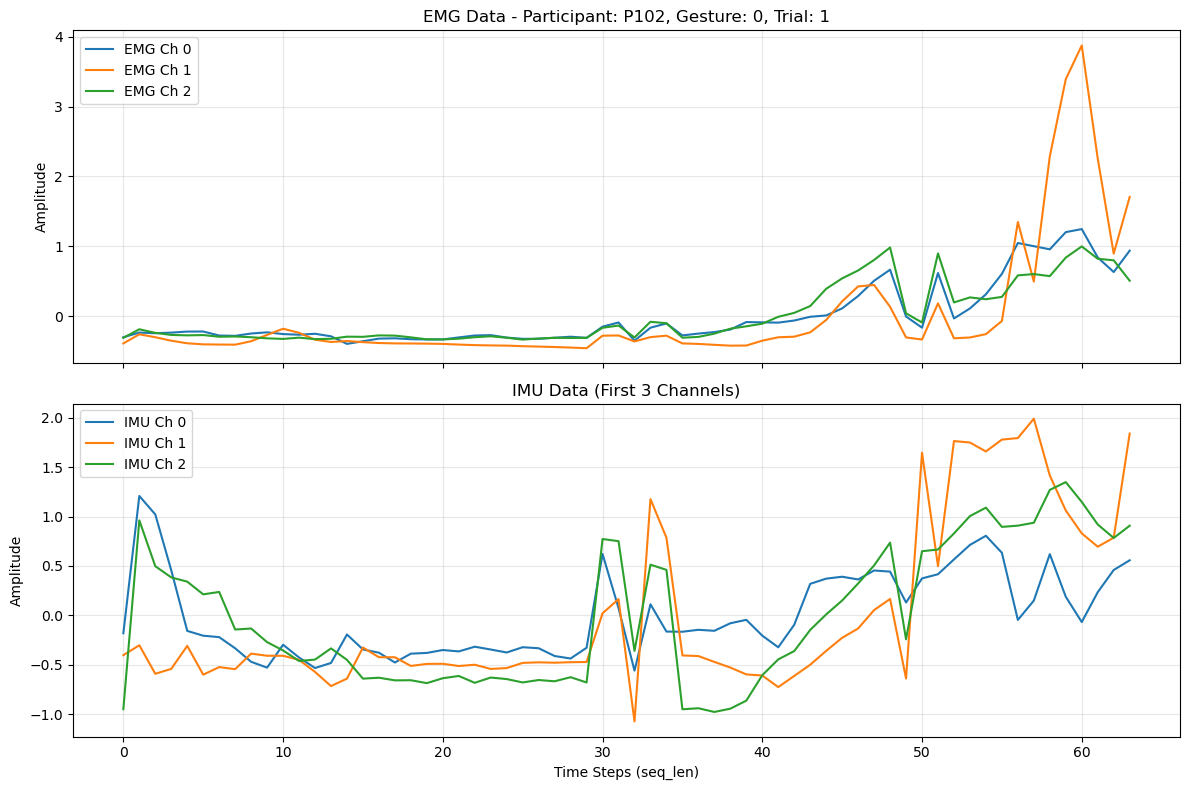

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 3 channels of EMG
for i in range(3):
    axes[0].plot(emg_data[:, i], label=f'EMG Ch {i}')
axes[0].set_title(f"EMG Data - Participant: {pid}, Gesture: {gesture_id}, Trial: {trial_idx+1}")
axes[0].set_ylabel("Amplitude")
axes[0].legend(loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 3 channels of IMU
if imu_data is not None:
    for i in range(3):
        axes[1].plot(imu_data[:, i], label=f'IMU Ch {i}')
    axes[1].set_title(f"IMU Data (First 3 Channels)")
    axes[1].set_ylabel("Amplitude")
    axes[1].legend(loc='upper left')
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, "No IMU data found for this entry", ha='center')

axes[1].set_xlabel("Time Steps (seq_len)")

plt.tight_layout()
plt.show()

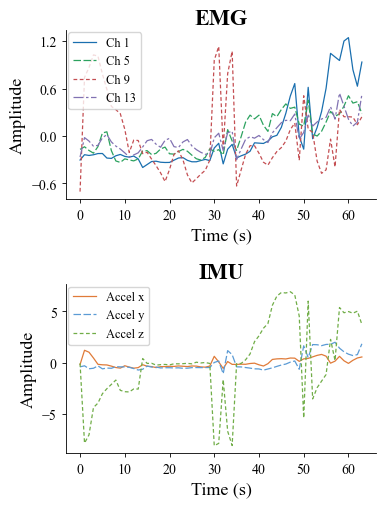

In [5]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "font.size":        10,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid":        False,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "axes.linewidth":   0.6,
    "lines.linewidth":  0.9,
    "legend.frameon":   True,
    "legend.fontsize":  9,
})

EMG_CHANNELS  = [0, 4, 8, 12]
IMU_CHANNELS  = [0, 1, 3]
EMG_COLORS    = ["#1a6faf", "#2ca25f", "#c44e52", "#8172b2"]
IMU_COLORS    = ["#e07b39", "#5b9bd5", "#70ad47"]
EMG_DASHES    = [(),        (6, 2),   (3, 2),    (8, 2, 2, 2)]
IMU_DASHES    = [(),        (6, 2),   (3, 2)]

TITLE_FONT = 16
LABEL_FONT = 13

# ── Figure layout ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(4.0, 5.5))
gs  = gridspec.GridSpec(2, 1, figure=fig, hspace=0.5)

ax_emg = fig.add_subplot(gs[0])
ax_imu = fig.add_subplot(gs[1])

# ── EMG panel ──────────────────────────────────────────────────────────────────
for rank, ch in enumerate(EMG_CHANNELS):
    ax_emg.plot(
        emg_data[:, ch],
        color=EMG_COLORS[rank],
        dashes=EMG_DASHES[rank],
        label=f"Ch {ch + 1}",
        linewidth=0.9,
    )

ax_emg.set_title("EMG", fontsize=TITLE_FONT, fontweight="bold", pad=4)
ax_emg.set_xlabel("Time (s)", fontsize=LABEL_FONT)
ax_emg.set_ylabel("Amplitude", fontsize=LABEL_FONT)
ax_emg.yaxis.set_major_locator(plt.MaxNLocator(4))
ax_emg.tick_params(axis='both', labelsize=10)
ax_emg.legend(loc="upper left", handlelength=1.8, borderaxespad=0.2)

# ── IMU panel ──────────────────────────────────────────────────────────────────
if imu_data is not None:
    imu_labels = ["Accel x", "Accel y", "Accel z"]
    for rank, ch in enumerate(IMU_CHANNELS):
        ax_imu.plot(
            imu_data[:, ch],
            color=IMU_COLORS[rank],
            dashes=IMU_DASHES[rank],
            label=imu_labels[rank],
            linewidth=0.9,
        )
    ax_imu.set_title("IMU", fontsize=TITLE_FONT, fontweight="bold", pad=4)
    ax_imu.set_xlabel("Time (s)", fontsize=LABEL_FONT)
    ax_imu.set_ylabel("Amplitude", fontsize=LABEL_FONT)
    ax_imu.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax_imu.tick_params(axis='both', labelsize=10)
    ax_imu.legend(loc="upper left", handlelength=1.8, borderaxespad=0.2)
else:
    raise ValueError(f"No IMU data for pid={pid}, gesture={gesture_id}, trial={trial_idx}")

# ── Export ─────────────────────────────────────────────────────────────────────
#plt.savefig("fig_data_example.pdf", dpi=500, bbox_inches="tight")
#plt.savefig("fig_data_example.png", dpi=500, bbox_inches="tight")
plt.show()

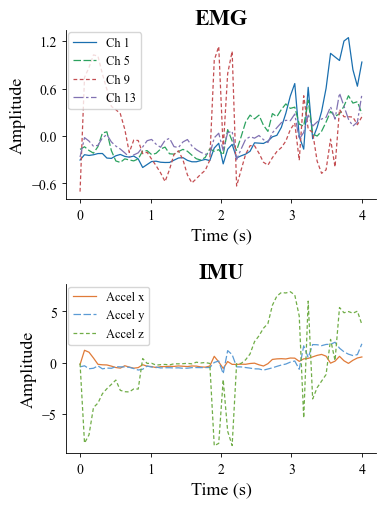

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "font.size":        10,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid":        False,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "axes.linewidth":   0.6,
    "lines.linewidth":  0.9,
    "legend.frameon":   True,
    "legend.fontsize":  9,
})

EMG_CHANNELS  = [0, 4, 8, 12]
IMU_CHANNELS  = [0, 1, 3]
EMG_COLORS    = ["#1a6faf", "#2ca25f", "#c44e52", "#8172b2"]
IMU_COLORS    = ["#e07b39", "#5b9bd5", "#70ad47"]
EMG_DASHES    = [(),        (6, 2),   (3, 2),    (8, 2, 2, 2)]
IMU_DASHES    = [(),        (6, 2),   (3, 2)]

TITLE_FONT = 16
LABEL_FONT = 13

# ── Figure layout ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(4.0, 5.5))
gs  = gridspec.GridSpec(2, 1, figure=fig, hspace=0.5)

ax_emg = fig.add_subplot(gs[0])
ax_imu = fig.add_subplot(gs[1])

time_emg = np.linspace(0, 4, len(emg_data))
if imu_data is not None:
    time_imu = np.linspace(0, 4, len(imu_data))

# ── EMG panel ──────────────────────────────────────────────────────────────────
for rank, ch in enumerate(EMG_CHANNELS):
    ax_emg.plot(
        time_emg, 
        emg_data[:, ch],
        color=EMG_COLORS[rank],
        dashes=EMG_DASHES[rank],
        label=f"Ch {ch + 1}",
        linewidth=0.9,
    )

ax_emg.set_title("EMG", fontsize=TITLE_FONT, fontweight="bold", pad=4)
ax_emg.set_xlabel("Time (s)", fontsize=LABEL_FONT)
ax_emg.set_ylabel("Amplitude", fontsize=LABEL_FONT)
ax_emg.yaxis.set_major_locator(plt.MaxNLocator(4))
ax_emg.tick_params(axis='both', labelsize=10)
ax_emg.legend(loc="upper left", handlelength=1.8, borderaxespad=0.2)

# ── IMU panel ──────────────────────────────────────────────────────────────────
if imu_data is not None:
    imu_labels = ["Accel x", "Accel y", "Accel z"]
    for rank, ch in enumerate(IMU_CHANNELS):
        ax_imu.plot(
            time_imu, 
            imu_data[:, ch],
            color=IMU_COLORS[rank],
            dashes=IMU_DASHES[rank],
            label=imu_labels[rank],
            linewidth=0.9,
        )
    ax_imu.set_title("IMU", fontsize=TITLE_FONT, fontweight="bold", pad=4)
    ax_imu.set_xlabel("Time (s)", fontsize=LABEL_FONT)
    ax_imu.set_ylabel("Amplitude", fontsize=LABEL_FONT)
    ax_imu.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax_imu.tick_params(axis='both', labelsize=10)
    ax_imu.legend(loc="upper left", handlelength=1.8, borderaxespad=0.2)
else:
    raise ValueError(f"No IMU data for pid={pid}, gesture={gesture_id}, trial={trial_idx}")

# ── Export ─────────────────────────────────────────────────────────────────────
#plt.savefig("EMG_IMU_chs.pdf", dpi=500, bbox_inches="tight")
plt.savefig("EMG_IMU_chs.png", dpi=500, bbox_inches="tight")
plt.show()